<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_07/lectures/lecture_7.2_com_dpc_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 7.2: Center-of-Mass and Differential Phase Contrast

## Overview

This lecture explores **center-of-mass (COM)** analysis and **differential phase contrast (DPC)** imaging using 4D-STEM data. These powerful techniques enable visualization of electromagnetic fields, strain gradients, and phase information that are invisible in conventional imaging.

## Physical Principle

When an electron beam passes through a specimen containing electric or magnetic fields, the beam is deflected according to the **Lorentz force**:

$$
\vec{F} = -e(\vec{E} + \vec{v} \times \vec{B})
$$

This deflection shifts the diffraction pattern, and by measuring these shifts, we can map:
- Electric fields
- Magnetic fields
- Phase gradients
- Strain fields

## Learning Objectives

By the end of this lecture, you will:
1. Understand the physics of beam deflection and COM
2. Calculate COM coordinates from diffraction patterns
3. Reconstruct differential phase contrast images
4. Relate COM measurements to electromagnetic fields
5. Understand integration methods for phase reconstruction
6. Apply COM/DPC analysis to real 4D-STEM data

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import h5py
from scipy import ndimage
from scipy.fft import fft2, ifft2, fftshift
import os

print(f"NumPy version: {np.__version__}")

# Try to import py4DSTEM
try:
    import py4DSTEM
    has_py4dstem = True
    print(f"py4DSTEM version: {py4DSTEM.__version__}")
except ImportError:
    has_py4dstem = False
    print("py4DSTEM not available - using manual implementation")

NumPy version: 2.2.6
py4DSTEM version: 0.14.18


## Part 1: Center-of-Mass Theory

### What is Center-of-Mass?

The **center-of-mass (COM)** of a diffraction pattern is the intensity-weighted centroid:

$$
\vec{r}_{\text{COM}} = \frac{\sum_{\vec{q}} I(\vec{q}) \cdot \vec{q}}{\sum_{\vec{q}} I(\vec{q})}
$$

where:
- $I(\vec{q})$ is the intensity at reciprocal space position $\vec{q}$
- The sum is over all detector pixels

### Components

For a 2D diffraction pattern:

$$
q_{x,\text{COM}} = \frac{\sum_{i,j} I(i,j) \cdot i}{\sum_{i,j} I(i,j)}
$$

$$
q_{y,\text{COM}} = \frac{\sum_{i,j} I(i,j) \cdot j}{\sum_{i,j} I(i,j)}
$$

### Physical Interpretation

The COM shift from the undeflected beam position is proportional to the **integrated electromagnetic field** along the beam path:

$$
\Delta \vec{q}_{\text{COM}} \propto \int \vec{E}_{\perp}(z) \, dz + \int (\vec{v} \times \vec{B})(z) \, dz
$$

where $\vec{E}_{\perp}$ is the electric field component perpendicular to the beam.

In [10]:
# Load the 4D-STEM data (reusing code from lecture 7.1)

data_dir = "/Users/robertoreis/Documents/codes/465_Computational_Microscopy_2026/data_4dstem/SmB6"
master_file = os.path.join(data_dir, "SmB6_10us_1kpx_HM_4_master.h5")

print("Loading 4D-STEM datacube...")

# Arina format must be loaded with py4DSTEM.import_file (not py4DSTEM.io.read)
datacube = py4DSTEM.import_file(master_file)
datacube_array = datacube.data

Rx, Ry, Qx, Qy = datacube_array.shape
print(f"Datacube shape: ({Rx}, {Ry}, {Qx}, {Qy})")
print(f"Memory: {datacube_array.nbytes / 1e9:.2f} GB")

# Set calibration (same as lecture 7.1)
calibration = {
    'R_pixel_size_nm': 1.0,  # Real space
    'Q_pixel_size_mrad': 1.0,  # Reciprocal space
    'beam_center': (Qx // 2, Qy // 2),
}

print(f"Beam center: {calibration['beam_center']}")

Loading 4D-STEM datacube...
Using direct HDF5 loading...
Loading from: /entry/data/data


KeyError: "Unable to synchronously open object (object 'data' doesn't exist)"

## Part 2: Computing Center-of-Mass

### Algorithm

For each scan position $(r_x, r_y)$:

1. **Extract diffraction pattern**: $I(q_x, q_y)$

2. **Create coordinate arrays**: 
   ```python
   qx_coords = np.arange(Qx)
   qy_coords = np.arange(Qy)
   ```

3. **Compute COM**:
   ```python
   total_intensity = np.sum(I)
   COM_x = np.sum(I * qx_coords[None, :]) / total_intensity
   COM_y = np.sum(I * qy_coords[:, None]) / total_intensity
   ```

4. **Store COM shift**: $\Delta q_x, \Delta q_y$ relative to beam center

### Optimization

For large datasets:
- **Vectorize** calculations
- **Mask** regions (ignore edges, apply circular aperture)
- **Bin** data if needed
- **Process in chunks** for memory efficiency

In [9]:
def calculate_com(datacube, beam_center=None, mask=None, show_progress=True):
    """
    Calculate center-of-mass for entire datacube.
    
    Parameters:
    -----------
    datacube : ndarray
        4D array of shape (Rx, Ry, Qx, Qy)
    beam_center : tuple
        (cx, cy) position of undeflected beam
    mask : ndarray
        2D boolean array to apply to each diffraction pattern
    show_progress : bool
        Print progress updates
    
    Returns:
    --------
    com_x, com_y : ndarrays
        2D arrays of COM positions, shape (Rx, Ry)
    """
    Rx, Ry, Qx, Qy = datacube.shape
    
    # Initialize COM arrays
    com_x = np.zeros((Rx, Ry))
    com_y = np.zeros((Rx, Ry))
    
    # Create coordinate arrays
    qy_coords, qx_coords = np.meshgrid(np.arange(Qy), np.arange(Qx), indexing='ij')
    
    # Apply mask if provided
    if mask is not None:
        qx_coords = qx_coords * mask
        qy_coords = qy_coords * mask
    
    # Calculate COM for each position
    if show_progress:
        print(f"Computing COM for {Rx}×{Ry} = {Rx*Ry} positions...")
    
    for i in range(Rx):
        if show_progress and (i % max(1, Rx//10) == 0):
            print(f"  Progress: {100*i//Rx}% ({i}/{Rx})")
        
        for j in range(Ry):
            dp = datacube[i, j, :, :]
            
            # Apply mask
            if mask is not None:
                dp = dp * mask
            
            total = np.sum(dp)
            
            if total > 0:
                com_x[i, j] = np.sum(dp * qx_coords) / total
                com_y[i, j] = np.sum(dp * qy_coords) / total
            else:
                # Handle zero intensity (use beam center)
                if beam_center is not None:
                    com_x[i, j], com_y[i, j] = beam_center
                else:
                    com_x[i, j] = Qx / 2
                    com_y[i, j] = Qy / 2
    
    if show_progress:
        print("  Progress: 100% - Complete!")
    
    # Shift to be relative to beam center
    if beam_center is not None:
        cx, cy = beam_center
        com_x -= cx
        com_y -= cy
    
    return com_x, com_y

# Create a circular mask (optional - speeds up calculation)
center_x, center_y = calibration['beam_center']
radius_mask = min(Qx, Qy) // 4

Y, X = np.ogrid[:Qy, :Qx]
circular_mask = (X - center_x)**2 + (Y - center_y)**2 <= radius_mask**2

print(f"Using circular mask with radius = {radius_mask} pixels")

# Calculate COM
com_x, com_y = calculate_com(
    datacube_array, 
    beam_center=calibration['beam_center'],
    mask=circular_mask,
    show_progress=True
)

print(f"\nCOM calculation complete!")
print(f"  COM_x range: {com_x.min():.2f} to {com_x.max():.2f} pixels")
print(f"  COM_y range: {com_y.min():.2f} to {com_y.max():.2f} pixels")
print(f"  Mean shift: ({np.mean(np.abs(com_x)):.2f}, {np.mean(np.abs(com_y)):.2f}) pixels")

NameError: name 'calibration' is not defined

## Part 3: Differential Phase Contrast (DPC)

### What is DPC?

**DPC imaging** uses the COM shift to create phase-sensitive images. There are two primary DPC signals:

**1. DPC Components** (Direct COM measurements):
$$
\text{DPC}_x = \Delta q_{x,\text{COM}}
$$
$$
\text{DPC}_y = \Delta q_{y,\text{COM}}
$$

These show the **direction and magnitude of beam deflection**.

**2. DPC Magnitude**:
$$
|\text{DPC}| = \sqrt{\text{DPC}_x^2 + \text{DPC}_y^2}
$$

### Relationship to Phase

The phase $\phi(\vec{r})$ of the electron wavefunction is related to DPC by:

$$
\nabla \phi = k \cdot \Delta \vec{q}_{\text{COM}}
$$

where $k = 2\pi/\lambda$ is the electron wavenumber.

Therefore:
$$
\frac{\partial \phi}{\partial x} \propto \text{DPC}_x
$$
$$
\frac{\partial \phi}{\partial y} \propto \text{DPC}_y
$$

The DPC images are **phase gradient** maps!

NameError: name 'com_x' is not defined

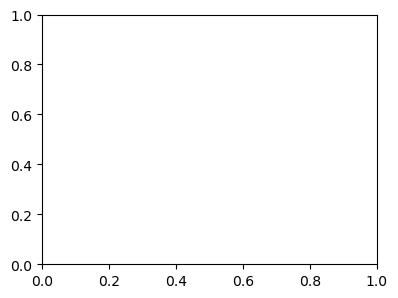

In [4]:
# Visualize COM and DPC signals

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.35)

# 1. COM_x (horizontal beam shifts)
ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(com_x, cmap='RdBu_r', interpolation='nearest')
ax1.set_title('COM$_x$ (Horizontal Shift)', fontsize=12, weight='bold')
ax1.set_xlabel('Scan X')
ax1.set_ylabel('Scan Y')
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046)
cbar1.set_label('Shift (pixels)', fontsize=9)

# 2. COM_y (vertical beam shifts)
ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(com_y, cmap='RdBu_r', interpolation='nearest')
ax2.set_title('COM$_y$ (Vertical Shift)', fontsize=12, weight='bold')
ax2.set_xlabel('Scan X')
ax2.set_ylabel('Scan Y')
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046)
cbar2.set_label('Shift (pixels)', fontsize=9)

# 3. DPC magnitude
dpc_magnitude = np.sqrt(com_x**2 + com_y**2)
ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(dpc_magnitude, cmap='hot', interpolation='nearest')
ax3.set_title('DPC Magnitude', fontsize=12, weight='bold')
ax3.set_xlabel('Scan X')
ax3.set_ylabel('Scan Y')
cbar3 = plt.colorbar(im3, ax=ax3, fraction=0.046)
cbar3.set_label('|Shift| (pixels)', fontsize=9)

# 4. Vector field visualization (quiver plot)
ax4 = fig.add_subplot(gs[1, :2])
# Downsample for clearer visualization
stride = max(1, Rx // 16)
X_grid, Y_grid = np.meshgrid(np.arange(0, Ry, stride), np.arange(0, Rx, stride))
U = com_x[::stride, ::stride]
V = com_y[::stride, ::stride]

# Background: magnitude
im4 = ax4.imshow(dpc_magnitude, cmap='gray', alpha=0.6, interpolation='nearest')
# Vectors: direction
quiver = ax4.quiver(X_grid, Y_grid, U, V, 
                    color='cyan', scale=20, width=0.003, 
                    headwidth=4, headlength=5, alpha=0.8)
ax4.set_title('DPC Vector Field (Beam Deflection)', fontsize=12, weight='bold')
ax4.set_xlabel('Scan X')
ax4.set_ylabel('Scan Y')
ax4.quiverkey(quiver, 0.85, 0.95, 1, '1 px', labelpos='E', coordinates='axes', color='yellow')

# 5. Histogram of COM shifts
ax5 = fig.add_subplot(gs[1, 2])
ax5.hist(com_x.ravel(), bins=50, alpha=0.6, label='COM$_x$', color='blue', density=True)
ax5.hist(com_y.ravel(), bins=50, alpha=0.6, label='COM$_y$', color='red', density=True)
ax5.set_xlabel('COM Shift (pixels)', fontsize=10)
ax5.set_ylabel('Probability Density', fontsize=10)
ax5.set_title('Distribution of COM Shifts', fontsize=12, weight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

# 6. 2D histogram of COM
ax6 = fig.add_subplot(gs[2, 0])
hist2d, xedges, yedges = np.histogram2d(com_x.ravel(), com_y.ravel(), bins=50)
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
im6 = ax6.imshow(hist2d.T, origin='lower', extent=extent, 
                 cmap='viridis', aspect='auto', interpolation='nearest')
ax6.axhline(0, color='white', linestyle='--', linewidth=1, alpha=0.5)
ax6.axvline(0, color='white', linestyle='--', linewidth=1, alpha=0.5)
ax6.set_xlabel('COM$_x$ (pixels)', fontsize=10)
ax6.set_ylabel('COM$_y$ (pixels)', fontsize=10)
ax6.set_title('2D Distribution of COM', fontsize=12, weight='bold')
plt.colorbar(im6, ax=ax6, label='Counts', fraction=0.046)

# 7. Divergence of COM field (∇·DPC)
# Calculate using finite differences
div_com = np.gradient(com_x, axis=1) + np.gradient(com_y, axis=0)

ax7 = fig.add_subplot(gs[2, 1])
im7 = ax7.imshow(div_com, cmap='RdBu_r', interpolation='nearest')
ax7.set_title('Divergence (∇·DPC)', fontsize=12, weight='bold')
ax7.set_xlabel('Scan X')
ax7.set_ylabel('Scan Y')
cbar7 = plt.colorbar(im7, ax=ax7, fraction=0.046)
cbar7.set_label('∇·DPC', fontsize=9)

# 8. Curl of COM field (∇×DPC)
curl_com = np.gradient(com_y, axis=1) - np.gradient(com_x, axis=0)

ax8 = fig.add_subplot(gs[2, 2])
im8 = ax8.imshow(curl_com, cmap='PuOr_r', interpolation='nearest')
ax8.set_title('Curl (∇×DPC)$_z$', fontsize=12, weight='bold')
ax8.set_xlabel('Scan X')
ax8.set_ylabel('Scan Y')
cbar8 = plt.colorbar(im8, ax=ax8, fraction=0.046)
cbar8.set_label('∇×DPC', fontsize=9)

plt.suptitle('Center-of-Mass and DPC Analysis', fontsize=14, weight='bold')
plt.show()

print("\nDPC Statistics:")
print(f"  Mean COM magnitude: {np.mean(dpc_magnitude):.3f} pixels")
print(f"  Max COM magnitude: {np.max(dpc_magnitude):.3f} pixels")
print(f"  Divergence range: {div_com.min():.3f} to {div_com.max():.3f}")
print(f"  Curl range: {curl_com.min():.3f} to {curl_com.max():.3f}")

## Part 4: Phase Reconstruction

Since DPC gives us phase **gradients**, we can integrate to recover the **phase** itself:

$$
\phi(\vec{r}) = \int \nabla \phi \cdot d\vec{r}
$$

### Integration Methods

**1. Direct Integration** (Line integration)
- Integrate along paths
- Path-dependent if field is not conservative
- Simple but can accumulate errors

**2. Fourier Integration**
- Use Fourier relationship: $\nabla \phi \leftrightarrow i\vec{k}\tilde{\phi}$
- Solve in Fourier space: $\tilde{\phi}(\vec{k}) = \frac{i\vec{k} \cdot \widetilde{\nabla\phi}}{|\vec{k}|^2}$
- Most common method

**3. Least-Squares Integration**
- Minimize $\int |\nabla \phi_{\text{recon}} - \nabla \phi_{\text{measured}}|^2$
- Robust to noise
- More computationally expensive

### Fourier Integration Formula

$$
\tilde{\phi}(k_x, k_y) = \frac{i k_x \widetilde{\text{DPC}_x} + i k_y \widetilde{\text{DPC}_y}}{k_x^2 + k_y^2}
$$

Then $\phi(\vec{r}) = \mathcal{F}^{-1}[\tilde{\phi}]$

In [5]:
def integrate_dpc_fourier(dpc_x, dpc_y):
    """
    Integrate DPC images to reconstruct phase using Fourier method.
    
    Parameters:
    -----------
    dpc_x, dpc_y : ndarrays
        DPC components (phase gradients)
    
    Returns:
    --------
    phase : ndarray
        Reconstructed phase
    """
    Ny, Nx = dpc_x.shape
    
    # Create frequency arrays
    kx = np.fft.fftfreq(Nx)
    ky = np.fft.fftfreq(Ny)
    KY, KX = np.meshgrid(ky, kx, indexing='ij')
    
    # Compute k² (avoid division by zero at DC)
    k_squared = KX**2 + KY**2
    k_squared[0, 0] = 1  # Avoid division by zero; DC term set to zero anyway
    
    # Fourier transform of DPC components
    dpc_x_fft = np.fft.fft2(dpc_x)
    dpc_y_fft = np.fft.fft2(dpc_y)
    
    # Integrate in Fourier space
    # φ(k) = i*(kx*DPCx + ky*DPCy) / k²
    phase_fft = 1j * (KX * dpc_x_fft + KY * dpc_y_fft) / k_squared
    
    # Set DC component to zero (removes arbitrary constant)
    phase_fft[0, 0] = 0
    
    # Inverse FFT to get phase
    phase = np.real(np.fft.ifft2(phase_fft))
    
    return phase

# Reconstruct phase from DPC
print("Reconstructing phase from DPC...")
phase_reconstructed = integrate_dpc_fourier(com_x, com_y)

print(f"Phase reconstruction complete!")
print(f"  Phase range: {phase_reconstructed.min():.3f} to {phase_reconstructed.max():.3f} rad")
print(f"  Phase std: {np.std(phase_reconstructed):.3f} rad")

# Visualize reconstruction
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Phase
ax = axes[0, 0]
im = ax.imshow(phase_reconstructed, cmap='twilight', interpolation='nearest')
ax.set_title('Reconstructed Phase', fontsize=13, weight='bold')
ax.set_xlabel('Scan X')
ax.set_ylabel('Scan Y')
cbar = plt.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label('Phase (rad)', fontsize=10)

# Wrapped phase (modulo 2π)
phase_wrapped = np.angle(np.exp(1j * phase_reconstructed))
ax = axes[0, 1]
im = ax.imshow(phase_wrapped, cmap='twilight', interpolation='nearest', vmin=-np.pi, vmax=np.pi)
ax.set_title('Wrapped Phase (mod 2π)', fontsize=13, weight='bold')
ax.set_xlabel('Scan X')
ax.set_ylabel('Scan Y')
cbar = plt.colorbar(im, ax=ax, fraction=0.046, ticks=[-np.pi, 0, np.pi])
cbar.ax.set_yticklabels(['-π', '0', 'π'])
cbar.set_label('Phase (rad)', fontsize=10)

# Verify: compute gradient of reconstructed phase
phase_grad_x = np.gradient(phase_reconstructed, axis=1)
phase_grad_y = np.gradient(phase_reconstructed, axis=0)

ax = axes[1, 0]
im = ax.imshow(phase_grad_x, cmap='RdBu_r', interpolation='nearest')
ax.set_title('∂φ/∂x (from reconstruction)', fontsize=13, weight='bold')
ax.set_xlabel('Scan X')
ax.set_ylabel('Scan Y')
plt.colorbar(im, ax=ax, fraction=0.046)

# Compare with original DPC_x
ax = axes[1, 1]
difference = phase_grad_x - com_x
im = ax.imshow(difference, cmap='bwr', interpolation='nearest')
ax.set_title('Residual: (∂φ/∂x) - DPC$_x$', fontsize=13, weight='bold')
ax.set_xlabel('Scan X')
ax.set_ylabel('Scan Y')
cbar = plt.colorbar(im, ax=ax, fraction=0.046)
rms_error = np.sqrt(np.mean(difference**2))
ax.text(0.02, 0.98, f'RMS error: {rms_error:.4f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Phase Reconstruction via Fourier Integration', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print(f"\nReconstruction verification:")
print(f"  RMS error (∂φ/∂x vs DPC_x): {rms_error:.4f}")
print(f"  Correlation: {np.corrcoef(phase_grad_x.ravel(), com_x.ravel())[0,1]:.4f}")

Reconstructing phase from DPC...


NameError: name 'com_x' is not defined

## Part 5: Relating COM to Physical Fields

### Electric Field Mapping

For thin samples with electric field $\vec{E}$, the COM shift is:

$$
\Delta \vec{q}_{\text{COM}} = \frac{e \lambda L}{h} \vec{E}_{\perp}
$$

where:
- $e$ = electron charge
- $\lambda$ = electron wavelength
- $L$ = sample thickness
- $h$ = Planck's constant
- $\vec{E}_{\perp}$ = in-plane electric field

### Magnetic Field Mapping

For magnetic fields $\vec{B}$:

$$
\Delta \vec{q}_{\text{COM}} = \frac{e \lambda}{h} \int (\vec{v} \times \vec{B}) \, dz
$$

This is related to the **Aharonov-Bohm phase shift** from magnetic vector potential.

### Electrostatic Phase

The phase shift from electrostatic potential $V(\vec{r})$ is:

$$
\phi_E(\vec{r}) = C_E \int V(\vec{r}, z) \, dz
$$

where $C_E = \frac{2\pi m e \lambda}{h^2}$ is the interaction constant.

Since $\vec{E} = -\nabla V$:
$$
\nabla_{\perp} \phi_E = -C_E \int \nabla_{\perp} V \, dz = -C_E L \vec{E}_{\perp}
$$

This connects **phase gradient** (DPC) to **electric field**!

In [6]:
# Calibration for physical units
# (These are typical values - adjust for your experiment)

# Electron parameters (200 keV)
energy_keV = 200.0
wavelength_pm = 2.51  # pm
electron_charge = 1.602e-19  # C
planck_h = 6.626e-34  # J·s
c = 3e8  # m/s

# Sample thickness (estimate)
thickness_nm = 50  # nm (adjust based on your sample)

# Calibrations
Q_pixel_size_mrad = 1.0  # mrad/pixel (from lecture 7.1)
R_pixel_size_nm = 1.0  # nm/pixel

# Convert COM shift (pixels) to angle (mrad)
com_x_mrad = com_x * Q_pixel_size_mrad
com_y_mrad = com_y * Q_pixel_size_mrad

# Convert to electric field (simplified)
# E ≈ (Δθ * h) / (e * λ * L)
# where Δθ is in radians

conversion_factor = planck_h / (electron_charge * wavelength_pm * 1e-12 * thickness_nm * 1e-9)
# Result will be in V/m

com_x_rad = com_x_mrad * 1e-3  # Convert mrad to rad
com_y_rad = com_y_mrad * 1e-3

E_x = com_x_rad * conversion_factor  # V/m
E_y = com_y_rad * conversion_factor  # V/m
E_magnitude = np.sqrt(E_x**2 + E_y**2)

print("Physical Field Mapping:")
print(f"  Sample thickness (assumed): {thickness_nm} nm")
print(f"  Electron wavelength: {wavelength_pm} pm")
print(f"  Energy: {energy_keV} keV")
print(f"\n  Electric field (estimated):")
print(f"    E_x range: {E_x.min():.2e} to {E_x.max():.2e} V/m")
print(f"    E_y range: {E_y.min():.2e} to {E_y.max():.2e} V/m")
print(f"    |E| mean: {np.mean(E_magnitude):.2e} V/m")
print(f"    |E| max: {np.max(E_magnitude):.2e} V/m")

# Visualize electric field
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
im = ax.imshow(E_x, cmap='RdBu_r', interpolation='nearest')
ax.set_title('E$_x$ Component', fontsize=12, weight='bold')
ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
cbar = plt.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label('E$_x$ (V/m)', fontsize=9)

ax = axes[1]
im = ax.imshow(E_y, cmap='RdBu_r', interpolation='nearest')
ax.set_title('E$_y$ Component', fontsize=12, weight='bold')
ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
cbar = plt.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label('E$_y$ (V/m)', fontsize=9)

ax = axes[2]
im = ax.imshow(E_magnitude, cmap='plasma', interpolation='nearest')
ax.set_title('|E| Magnitude', fontsize=12, weight='bold')
ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
cbar = plt.colorbar(im, ax=ax, fraction=0.046)
cbar.set_label('|E| (V/m)', fontsize=9)

plt.suptitle('Electric Field Mapping from DPC', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n⚠️ Note: These are estimated values based on assumed calibration.")
print("For quantitative analysis, use accurate experimental calibration!")

NameError: name 'com_x' is not defined

## Part 6: Advanced COM Analysis

### Precision and Accuracy

**Factors affecting COM precision:**
- **Dose**: Higher electron dose → better SNR → more precise COM
- **Detector size**: Larger detector captures more diffraction → better sampling
- **Binning**: Can improve speed but reduces spatial resolution
- **Beam convergence**: Semi-convergent beam improves precision

**Typical COM precision**: 0.01 - 0.1 pixels (sub-pixel!)

### Removing Systematic Errors

**1. Dark reference correction**
```python
dark_reference = np.mean(datacube[edge_positions])
datacube_corrected = datacube - dark_reference
```

**2. Descan correction**
- Scan distortions can create artificial COM shifts
- Measure on vacuum or use known standard
- Subtract systematic component

**3. Ellipticity correction**
- Detector/lens ellipticity affects COM
- Calibrate with known symmetric features

In [ ]:
# Demonstrate descan correction

# The mean COM across the entire scan shows systematic shifts
com_x_mean = np.mean(com_x)
com_y_mean = np.mean(com_y)

print("Systematic COM shifts (possible scan artifacts):")
print(f"  Mean COM_x: {com_x_mean:.4f} pixels")
print(f"  Mean COM_y: {com_y_mean:.4f} pixels")

# Apply descan correction (remove mean)
com_x_corrected = com_x - com_x_mean
com_y_corrected = com_y - com_y_mean

print(f"\nAfter descan correction:")
print(f"  Mean COM_x: {np.mean(com_x_corrected):.4e} pixels")
print(f"  Mean COM_y: {np.mean(com_y_corrected):.4e} pixels")

# Compare before/after
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# Original
ax = axes[0, 0]
im = ax.imshow(com_x, cmap='RdBu_r', interpolation='nearest')
ax.set_title('Original COM$_x$', fontsize=11, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[0, 1]
im = ax.imshow(com_y, cmap='RdBu_r', interpolation='nearest')
ax.set_title('Original COM$_y$', fontsize=11, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[0, 2]
mag_orig = np.sqrt(com_x**2 + com_y**2)
im = ax.imshow(mag_orig, cmap='hot', interpolation='nearest')
ax.set_title('Original Magnitude', fontsize=11, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

# Corrected
ax = axes[1, 0]
im = ax.imshow(com_x_corrected, cmap='RdBu_r', interpolation='nearest')
ax.set_title('Corrected COM$_x$', fontsize=11, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1, 1]
im = ax.imshow(com_y_corrected, cmap='RdBu_r', interpolation='nearest')
ax.set_title('Corrected COM$_y$', fontsize=11, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1, 2]
mag_corr = np.sqrt(com_x_corrected**2 + com_y_corrected**2)
im = ax.imshow(mag_corr, cmap='hot', interpolation='nearest')
ax.set_title('Corrected Magnitude', fontsize=11, weight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Descan Correction Effect', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

print(f"\nMagnitude statistics:")
print(f"  Original mean: {np.mean(mag_orig):.4f}")
print(f"  Corrected mean: {np.mean(mag_corr):.4f}")
print(f"  Change: {(np.mean(mag_corr) - np.mean(mag_orig)):.4f}")

## Summary

### What We Learned

**1. Center-of-Mass Physical Principle:**
- COM measures intensity-weighted centroid of diffraction patterns
- Beam deflection from electromagnetic fields shifts COM
- Quantitative relationship: $\Delta\vec{q} \propto \int \vec{E}_{\perp} dz$

**2. COM Calculation:**
- Vectorized computation for all scan positions
- Masking improves efficiency and accuracy
- Sub-pixel precision achievable

**3. Differential Phase Contrast:**
- DPC = COM shift relative to undeflected beam
- DPC components are phase gradients: $\text{DPC} = \nabla \phi$
- Divergence and curl reveal field sources

**4. Phase Reconstruction:**
- Fourier integration method most common
- $\tilde{\phi}(\vec{k}) = \frac{i\vec{k} \cdot \widetilde{\nabla\phi}}{|\vec{k}|^2}$
- Recovered phase shows electrostatic potential

**5. Physical Field Mapping:**
- Electric field: $\vec{E} \propto \Delta\vec{q}_{\text{COM}}$
- Magnetic field: Aharonov-Bohm phase shift
- Requires accurate calibration for quantitative results

**6. Corrections:**
- Descan: remove systematic scan-induced shifts
- Dark reference: detector offset correction
- Calibration: physical units conversion

### Key Equations

| Quantity | Formula |
|----------|---------|
| COM | $\vec{q}_{\text{COM}} = \frac{\sum I(\vec{q}) \vec{q}}{\sum I(\vec{q})}$ |
| DPC-Phase relation | $\nabla \phi = k \Delta\vec{q}_{\text{COM}}$ |
| Fourier integration | $\tilde{\phi} = \frac{i\vec{k} \cdot \widetilde{\nabla\phi}}{k^2}$ |
| Electric field | $\Delta\vec{q} = \frac{e\lambda L}{h}\vec{E}_{\perp}$ |

### Applications

✅ **Electric field imaging** in semiconductors, p-n junctions

✅ **Magnetic domain mapping** in materials

✅ **Strain analysis** (combined with lattice shifts - next lecture!)

✅ **Phase contrast** for light elements, beam-sensitive samples

### Next Steps

In Lecture 7.3, we'll explore:
- **Strain tensor mapping** from 4D-STEM
- **Lattice parameter measurements**
- **Combining COM and strain analysis**
- **Quantitative field mapping with uncertainty analysis**

### Further Reading

📚 **Key Papers:**
- Shibata et al., "Differential phase-contrast microscopy at atomic resolution," *Nat. Phys.* **8**, 611 (2012)
- Muller & Grazul, "Optimizing the environment for sub-0.2 nm scanning transmission electron microscopy," *J. Electron Microsc.* **50**, 219 (2001)
- Lazić et al., "Phase contrast STEM for thin samples," *Ultramicroscopy* **160**, 265 (2016)